<a href="https://colab.research.google.com/github/Raajarapu/COLAB_practice/blob/main/MLalgo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement
### In this project, we aim to evaluate the performance of various supervised and unsupervised learning algorithms on two distinct datasets: the Adult dataset for classification and regression tasks, and the Iris dataset for clustering tasks. For the Adult dataset, the objective is to predict whether an individual's income exceeds $50K/yr based on census data, using models such as Random Forest, GBM, and SVM. For the Iris dataset, the goal is to group iris samples into clusters without predefined labels, employing clustering techniques such as K-Means, DBSCAN, and GMM. The evaluation of these models will be based on metrics like accuracy, precision, recall, silhouette score, and ARI, providing insights into the strengths and weaknesses of each algorithm in different contexts.

### This analysis will help in understanding the applicability of these algorithms and contribute to better decision-making in machine learning tasks, demonstrating their effectiveness in classification, regression, and clustering scenarios.

In [ ]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, precision_score,recall_score, f1_score, silhouette_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score

# Load the dataset
data = pd.read_csv('adult.csv')

# Preprocess the dataset
data = data.dropna()  # Drop rows with missing values

# Encode categorical variables
label_encoders = {}
for column in data.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

# Select relevant features and target
X = data.drop('income', axis=1)
y = data['income']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Normalizing the dataset
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Standard Scaler
## The Standard Scaler is a tool used to standardize the features of your data before feeding it into a machine learning model. Standardization here means that the data will be transformed to have a mean of 0 and a standard deviation of 1. This is important because many machine learning algorithms perform better when the data is standardized, especially those that calculate distances between data points, such as k-nearest neighbors or support vector machines.

# Label Encoder
## The Label Encoder is used to convert categorical labels into numeric labels. This is necessary because most machine learning models require numeric input rather than categorical input. The encoder assigns a unique integer to each category.

In [ ]:
data.head() # Top five rows

NameError: name 'data' is not defined

In [ ]:
data.tail()  # Last five rows

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32556,22,4,310152,15,10,4,11,1,4,1,0,0,40,39,0
32557,27,4,257302,7,12,2,13,5,4,0,0,0,38,39,0
32558,40,4,154374,11,9,2,7,0,4,1,0,0,40,39,1
32559,58,4,151910,11,9,6,1,4,4,0,0,0,40,39,0
32560,22,4,201490,11,9,4,1,3,4,1,0,0,20,39,0


In [ ]:
data.info() # information about the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  int64
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  int64
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  int64
 6   occupation      32561 non-null  int64
 7   relationship    32561 non-null  int64
 8   race            32561 non-null  int64
 9   sex             32561 non-null  int64
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  int64
 14  income          32561 non-null  int64
dtypes: int64(15)
memory usage: 3.7 MB


In [ ]:
data.describe() # Describing the dataset

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
count,32561.000000,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,3.868892,1.897784e+05,10.298210,10.080679,2.611836,6.572740,1.446362,3.665858,0.669205,1077.648844,87.303830,40.437456,36.718866,0.240810
std,13.640433,1.455960,1.055500e+05,3.870264,2.572720,1.506222,4.228857,1.606771,0.848806,0.470506,7385.292085,402.960219,12.347429,7.823782,0.427581
min,17.000000,0.000000,1.228500e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,28.000000,4.000000,1.178270e+05,9.000000,9.000000,2.000000,3.000000,0.000000,4.000000,0.000000,0.000000,0.000000,40.000000,39.000000,0.000000
50%,37.000000,4.000000,1.783560e+05,11.000000,10.000000,2.000000,7.000000,1.000000,4.000000,1.000000,0.000000,0.000000,40.000000,39.000000,0.000000
75%,48.000000,4.000000,2.370510e+05,12.000000,12.000000,4.000000,10.000000,3.000000,4.000000,1.000000,0.000000,0.000000,45.000000,39.000000,0.000000
max,90.000000,8.000000,1.484705e+06,15.000000,16.000000,6.000000,14.000000,5.000000,4.000000,1.000000,99999.000000,4356.000000,99.000000,41.000000,1.000000


In [ ]:
data.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


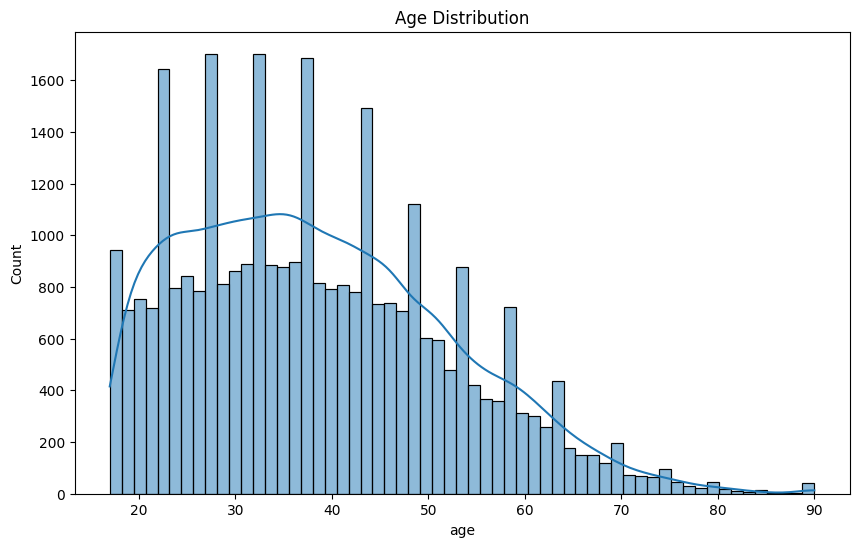

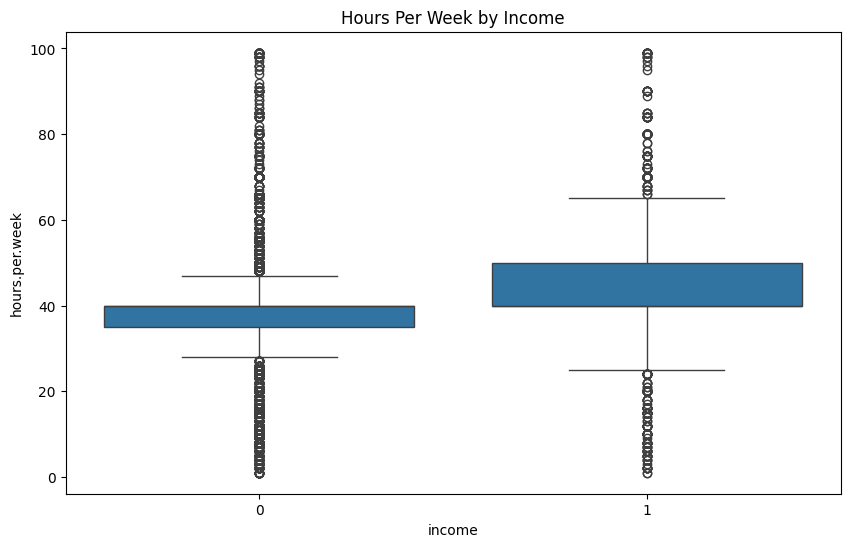

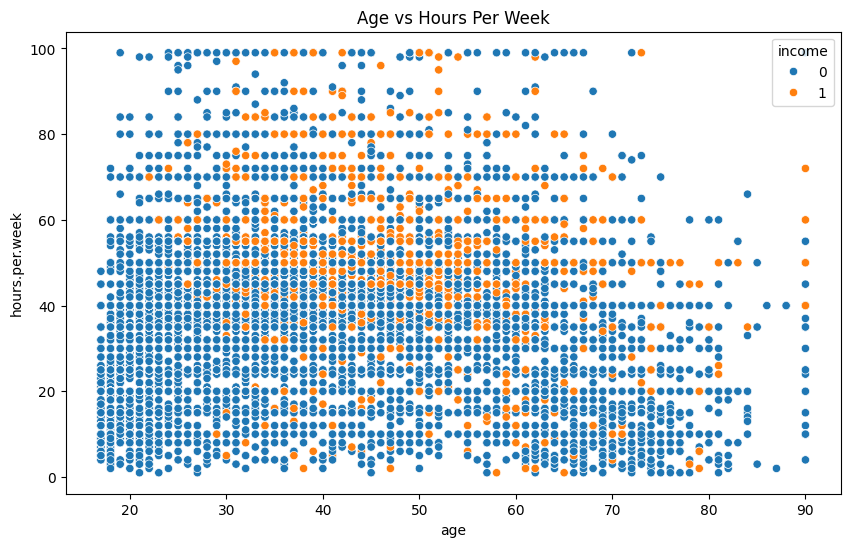

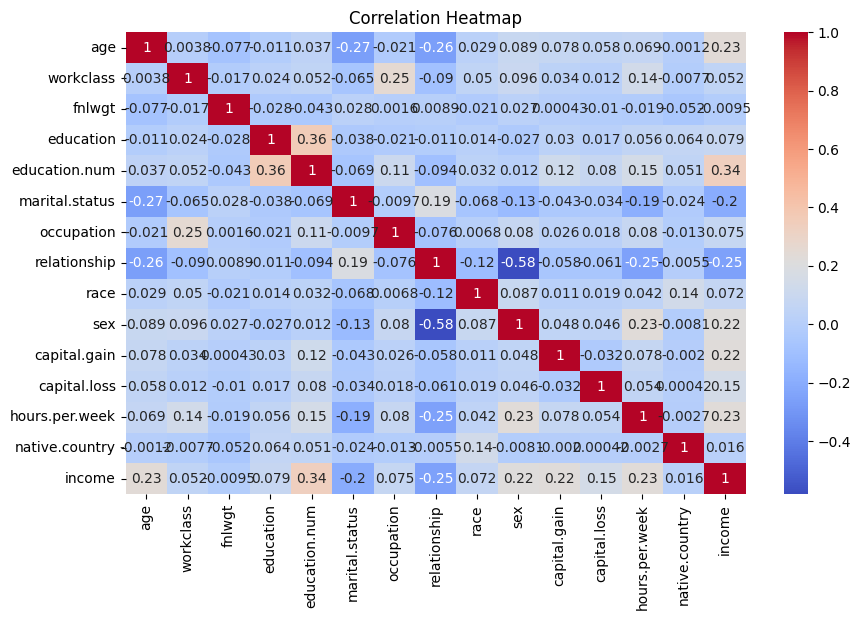

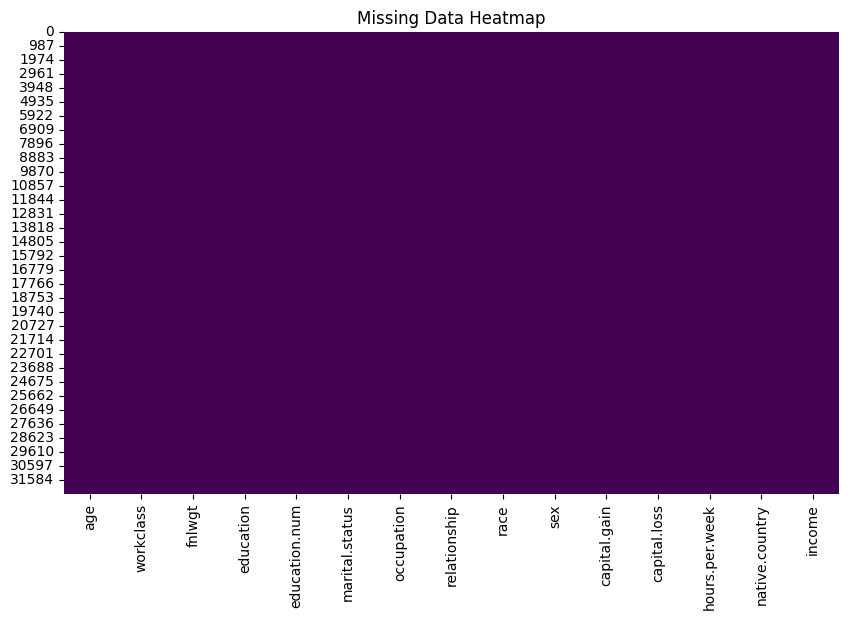

In [ ]:
# Univariate Analysis
plt.figure(figsize=(10, 6))
sns.histplot(data['age'], kde=True)
plt.title('Age Distribution')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='income', y='hours.per.week', data=data)
plt.title('Hours Per Week by Income')
plt.show()

# Bivariate Analysis
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='hours.per.week', hue='income', data=data)
plt.title('Age vs Hours Per Week')
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Missing Data
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()


# Linear Regression
Linear Regression is a fundamental and widely used algorithm in supervised machine learning. It's primarily used for predicting continuous numerical values and for understanding relationships between variables.

Basic Concept:
Linear Regression models the relationship between a dependent variable (target) and one or more independent variables (features) by fitting a linear equation to observed data. The goal is to find the line (or hyperplane in higher dimensions) that best fits the data, minimizing the difference between predicted and actual values.

Mathematical Representation:
The standard form of a linear regression equation is:

𝑌
=
𝛽
0
+
𝛽
1
𝑋
1
+
𝛽
2
𝑋
2
+
.
.
.
+
𝛽
𝑛
𝑋
𝑛
+
𝜖
Where:

𝑌
 is the dependent variable we aim to predict.

𝑋
1
,
𝑋
2
,
.
.
.
,
𝑋
𝑛
 are the independent variables.

𝛽
0
 is the intercept of the regression line.

𝛽
1
,
𝛽
2
,
.
.
.
,
𝛽
𝑛
 are the coefficients (weights) that represent the impact of each independent variable.

𝜖
 is the error term (residual), which accounts for the variation in
𝑌
 not explained by the linear relationship.

In [ ]:
from sklearn.linear_model import LinearRegression

# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
y_pred_lin = lin_reg.predict(X_test_scaled)

# Metrics for Linear Regression
mse_lin = mean_squared_error(y_test, y_pred_lin)
rmse_lin = np.sqrt(mse_lin)
mae_lin = mean_absolute_error(y_test, y_pred_lin)
r2_lin = r2_score(y_test, y_pred_lin)

# Print Metrics
print(f'Linear Regression - MSE: {mse_lin}, RMSE: {rmse_lin}, MAE: {mae_lin}, R2: {r2_lin}')


Linear Regression - MSE: 0.13570004717242876, RMSE: 0.36837487315563305, MAE: 0.29427794114257655, R2: 0.2591435453777434


# Logistic Regression
Logistic Regression is a popular supervised machine learning algorithm used for classification tasks. It is used to predict the probability of a binary outcome (1/0, Yes/No, True/False) based on one or more independent variables. Unlike linear regression, which predicts continuous values, logistic regression predicts categorical outcomes.

Basic Concept:
The fundamental idea behind logistic regression is to model the probability that a given input belongs to a particular class. It uses the logistic function, also known as the sigmoid function, to map predicted values to probabilities.

Mathematical Representation:
The logistic regression model estimates the probability
𝑃
 that the dependent variable
𝑌
 belongs to a particular class (say 1) as:

𝑃
(
𝑌
=
1
)
=
1
1
+
𝑒
−
(
𝛽
0
+
𝛽
1
𝑋
1
+
𝛽
2
𝑋
2
+
.
.
.
+
𝛽
𝑛
𝑋
𝑛
)
Where:

𝑌
 is the dependent variable (binary outcome).

𝑋
1
,
𝑋
2
,
.
.
.
,
𝑋
𝑛
 are the independent variables.

𝛽
0
 is the intercept.

𝛽
1
,
𝛽
2
,
.
.
.
,
𝛽
𝑛
 are the coefficients that represent the weight of each independent variable.

𝑒
 is the base of the natural logarithm (approximately 2.71828).

The sigmoid function
𝜎
(
𝑧
)
 maps any real-valued number into a value between 0 and 1:

𝜎
(
𝑧
)
=
1
1
+
𝑒
−
𝑧

In [ ]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

# Metrics for Logistic Regression
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

# Print Metrics
print(f'Logistic Regression - Accuracy: {accuracy_log}, Precision: {precision_log}, Recall: {recall_log}, F1: {f1_log}')


Logistic Regression - Accuracy: 0.8203500870099294, Precision: 0.7065663474692202, Recall: 0.4378974141585418, F1: 0.5406961528395708




# Random Forest

Random Forest is a versatile and powerful ensemble learning algorithm used for both classification and regression tasks. It operates by constructing multiple decision trees during training and outputting the class that is the mode of the classes (classification) or the mean prediction (regression) of the individual trees.

#### Basic Concept:
The Random Forest algorithm builds a "forest" of decision trees. Each decision tree is trained on a random subset of the training data, and each node in the tree considers a random subset of features when splitting. This randomness helps in creating a diverse set of decision trees, which in turn improves the robustness and accuracy of the final model.

#### Key Characteristics:
- **Ensemble Method**: Combines multiple decision trees to create a more accurate and stable model.
- **Bootstrap Aggregation (Bagging)**: Each tree is trained on a random subset of the training data, sampled with replacement. This technique is known as bootstrapping.
- **Random Subset of Features**: At each split in a tree, a random subset of features is considered. This randomness helps to reduce overfitting and ensures that the trees are less correlated.

### Random Forest for Classification:
In classification tasks, the goal of Random Forest is to predict the categorical class label for a given input. The process involves:
1. **Training**: Multiple decision trees are trained on random subsets of the training data. Each tree independently makes a prediction.
2. **Prediction**: For a given input, each tree in the forest predicts a class label. The final prediction is determined by majority voting among all the trees. The class label that receives the most votes is chosen as the final output.

**Advantages for Classification:**
- **High Accuracy**: The ensemble approach typically provides better predictive accuracy than individual decision trees.
- **Robust to Overfitting**: The randomness in bootstrapping and feature selection helps to prevent overfitting.
- **Feature Importance**: Random Forest provides an estimate of the importance of each feature, which can be useful for feature selection.

### Random Forest for Regression:
In regression tasks, the goal of Random Forest is to predict a continuous numerical value. The process involves:
1. **Training**: Multiple decision trees are trained on random subsets of the training data. Each tree independently makes a prediction.
2. **Prediction**: For a given input, each tree in the forest predicts a numerical value. The final prediction is obtained by averaging the predictions from all the trees.

**Advantages for Regression:**
- **Accurate Predictions**: The ensemble approach improves the accuracy of predictions by reducing variance.
- **Robust to Outliers**: Random Forest is less sensitive to outliers compared to individual decision trees.
- **Feature Importance**: Similar to classification, Random Forest provides an estimate of the importance of each feature.

### Advantages of Random Forest:
- **High Accuracy**: The ensemble method generally produces more accurate and reliable predictions.
- **Robustness to Overfitting**: The combination of multiple trees, along with the randomness in data and feature selection, helps to reduce overfitting.
- **Scalability**: Can handle large datasets with higher dimensionality.
- **Handles Missing Values**: Random Forest can handle missing data by using median/mode of predictions.
- **Feature Importance**: Provides an estimate of feature importance, which can be useful for identifying significant predictors.

### Limitations of Random Forest:
- **Computationally Intensive**: Training and predicting with multiple decision trees can be computationally expensive, especially with large datasets.
- **Interpretability**: While individual decision trees are easy to interpret, the combined model of a Random Forest can be more challenging to understand.

Random Forest is a highly effective and flexible algorithm that excels in a wide range of machine learning tasks, offering excellent performance in both classification and regression problems. It is widely used in various applications, including medical diagnosis, finance, and marketing.


In [ ]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

# Random Forest Classifier
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train_scaled, y_train)
y_pred_rf_clf = rf_clf.predict(X_test_scaled)

# Metrics for Random Forest Classifier
accuracy_rf_clf = accuracy_score(y_test, y_pred_rf_clf)
precision_rf_clf = precision_score(y_test, y_pred_rf_clf)
recall_rf_clf = recall_score(y_test, y_pred_rf_clf)
f1_rf_clf = f1_score(y_test, y_pred_rf_clf)

# Print Metrics for Random Forest Classifier
print(f'Random Forest Classifier - Accuracy: {accuracy_rf_clf}, Precision: {precision_rf_clf}, Recall: {recall_rf_clf}, F1: {f1_rf_clf}')

# Random Forest Regressor
rf_reg = RandomForestRegressor()
rf_reg.fit(X_train_scaled, y_train)
y_pred_rf_reg = rf_reg.predict(X_test_scaled)

# Metrics for Random Forest Regressor
mse_rf_reg = mean_squared_error(y_test, y_pred_rf_reg)
rmse_rf_reg = np.sqrt(mse_rf_reg)
mae_rf_reg = mean_absolute_error(y_test, y_pred_rf_reg)
r2_rf_reg = r2_score(y_test, y_pred_rf_reg)

# Print Metrics for Random Forest Regressor
print(f'Random Forest Regressor - MSE: {mse_rf_reg}, RMSE: {rmse_rf_reg}, MAE: {mae_rf_reg}, R2: {r2_rf_reg}')


Random Forest Classifier - Accuracy: 0.8563824342307299, Precision: 0.7492179353493222, Recall: 0.6091564222128021, F1: 0.6719663315407997
Random Forest Regressor - MSE: 0.10529987716245266, RMSE: 0.3244994255194494, MAE: 0.19297266864571602, R2: 0.42511373214478787


# Decision Trees

Decision Trees are a popular and intuitive type of supervised learning algorithm used for both classification and regression tasks. They work by recursively splitting the data into subsets based on the values of the input features, creating a tree-like model of decisions.

#### Basic Concept:
A Decision Tree consists of nodes and branches. Each node represents a feature (or attribute) in the dataset, and each branch represents a decision rule or condition based on that feature. The tree starts with a root node and splits the data at each node based on the best feature until it reaches the leaf nodes, which represent the final output (class label or numerical value).

### 1. Decision Trees for Classification:
In classification tasks, Decision Trees are used to predict the categorical class label for a given input.

#### Process:
1. **Root Node**: The tree starts with a root node representing the entire dataset.
2. **Splitting**: The data is split at each node based on the feature that provides the best separation of the classes (using metrics like Gini impurity or information gain).
3. **Leaf Nodes**: The process continues until it reaches the leaf nodes, which represent the final class labels.
4. **Prediction**: For a given input, the decision tree follows the path from the root to a leaf node based on the feature values, and the class label at the leaf node is the final prediction.

#### Example Scenario:
Imagine a decision tree for classifying whether a customer will purchase a product based on their age and income level. The tree would split the data based on age and income, creating branches for different age and income ranges, and finally predict whether the customer will purchase the product.

**Advantages for Classification:**
- **Interpretability**: Decision trees are easy to understand and interpret, as they mimic human decision-making.
- **Flexibility**: They can handle both numerical and categorical data.
- **No Assumptions**: They do not require assumptions about the distribution of data.

### 2. Decision Trees for Regression:
In regression tasks, Decision Trees are used to predict continuous numerical values.

#### Process:
1. **Root Node**: The tree starts with a root node representing the entire dataset.
2. **Splitting**: The data is split at each node based on the feature that minimizes the variance (or another measure of impurity) in the target variable.
3. **Leaf Nodes**: The process continues until it reaches the leaf nodes, which represent the final numerical values.
4. **Prediction**: For a given input, the decision tree follows the path from the root to a leaf node based on the feature values, and the numerical value at the leaf node is the final prediction.

#### Example Scenario:
Imagine a decision tree for predicting the price of a house based on features like the number of bedrooms, square footage, and location. The tree would split the data based on these features, creating branches for different ranges, and finally predict the house price.

**Advantages for Regression:**
- **Simplicity**: Decision trees are simple to understand and implement.
- **Flexibility**: They can capture non-linear relationships between features and the target variable.
- **Handling Missing Values**: They can handle missing data by splitting on surrogate features.

### Advantages of Decision Trees:
- **Easy to Interpret**: Decision trees are intuitive and easy to visualize, making them useful for understanding complex datasets.
- **Non-Parametric**: They do not assume any specific distribution of the data.
- **Feature Importance**: Decision trees provide insights into the importance of different features.

### Limitations of Decision Trees:
- **Overfitting**: Decision trees can easily overfit the training data, especially with deep trees.
- **Variance**: Single decision trees can be unstable and sensitive to small changes in the data.
- **Scalability**: They may not perform well with very large datasets or high-dimensional data.

Decision Trees are a foundational algorithm in machine learning, valued for their simplicity and interpretability. They serve as the building blocks for more advanced ensemble methods like Random Forests and Gradient Boosting.


In [ ]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# Decision Tree Classifier
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train_scaled, y_train)
y_pred_dt_clf = dt_clf.predict(X_test_scaled)

# Metrics for Decision Tree Classifier
accuracy_dt_clf = accuracy_score(y_test, y_pred_dt_clf)
precision_dt_clf = precision_score(y_test, y_pred_dt_clf)
recall_dt_clf = recall_score(y_test, y_pred_dt_clf)
f1_dt_clf = f1_score(y_test, y_pred_dt_clf)

# Print Metrics for Decision Tree Classifier
print(f'Decision Tree Classifier - Accuracy: {accuracy_dt_clf}, Precision: {precision_dt_clf}, Recall: {recall_dt_clf}, F1: {f1_dt_clf}')

# Decision Tree Regressor
dt_reg = DecisionTreeRegressor()
dt_reg.fit(X_train_scaled, y_train)
y_pred_dt_reg = dt_reg.predict(X_test_scaled)

# Metrics for Decision Tree Regressor
mse_dt_reg = mean_squared_error(y_test, y_pred_dt_reg)
rmse_dt_reg = np.sqrt(mse_dt_reg)
mae_dt_reg = mean_absolute_error(y_test, y_pred_dt_reg)
r2_dt_reg = r2_score(y_test, y_pred_dt_reg)

# Print Metrics for Decision Tree Regressor
print(f'Decision Tree Regressor - MSE: {mse_dt_reg}, RMSE: {rmse_dt_reg}, MAE: {mae_dt_reg}, R2: {r2_dt_reg}')


Decision Tree Classifier - Accuracy: 0.808475790766711, Precision: 0.6024349286314021, Recall: 0.6083086053412463, F1: 0.6053575195106518
Decision Tree Regressor - MSE: 0.18947691677756168, RMSE: 0.435289463205304, MAE: 0.18947691677756168, R2: -0.034452085475043415


# Support Vector Machines (SVM)

Support Vector Machines (SVM) are a set of supervised learning methods used for classification, regression, and outlier detection. They are particularly known for their effectiveness in high-dimensional spaces and their ability to handle non-linear data using kernel functions.

#### Basic Concept:
SVM works by finding the optimal hyperplane that best separates the data into different classes (for classification) or fits the data (for regression). The key idea is to maximize the margin between the data points of different classes, ensuring that the model generalizes well to new data.

### 1. SVM for Classification:
In classification tasks, SVM aims to find the hyperplane that best separates the data points of different classes. The hyperplane is chosen to maximize the margin between the closest points (support vectors) of each class.

#### Process:
1. **Linear SVM**: For linearly separable data, SVM finds the hyperplane that maximizes the margin between the two classes.
2. **Non-Linear SVM**: For non-linearly separable data, SVM uses kernel functions (e.g., polynomial, radial basis function) to map the data into a higher-dimensional space where it becomes linearly separable.
3. **Support Vectors**: The data points closest to the hyperplane are called support vectors. These points are critical in defining the position of the hyperplane.

#### Example Scenario:
Imagine an SVM model classifying emails as either spam or not spam. The model would find the optimal hyperplane that separates the spam emails from non-spam emails based on features like word frequency and email length.

**Advantages for Classification:**
- **Effective in High-Dimensional Spaces**: SVM works well with large feature sets.
- **Robust to Overfitting**: Especially in high-dimensional spaces, SVM can be robust to overfitting.
- **Kernel Trick**: Allows SVM to handle non-linear relationships by mapping data into higher-dimensional spaces.

### 2. SVM for Regression (SVR):
In regression tasks, SVM is known as Support Vector Regression (SVR). SVR aims to find a function that deviates from the actual observed values by a value no greater than a specified threshold (epsilon), while still being as flat as possible.

#### Process:
1. **Epsilon-Insensitive Tube**: SVR defines a margin of tolerance (epsilon) within which errors are not penalized.
2. **Optimization**: SVR finds the hyperplane (or regression line) that fits the data while minimizing the error, subject to the constraint that the deviations from the actual values are within the epsilon margin.
3. **Support Vectors**: Similar to classification, the data points that lie on or outside the epsilon margin are the support vectors, which are critical in defining the regression function.

#### Example Scenario:
Imagine an SVR model predicting house prices based on features like the number of bedrooms, square footage, and location. The model would find the regression line that fits the data within the specified epsilon margin.

**Advantages for Regression:**
- **Flexibility**: Can handle both linear and non-linear regression problems.
- **Robustness**: Provides robust predictions by focusing on the support vectors and ignoring small deviations within the epsilon margin.

### Advantages of SVM:
- **High-Dimensionality**: Effective in high-dimensional spaces and with a large number of features.
- **Versatility**: Can be used for both linear and non-linear data through kernel functions.
- **Generalization**: Focuses on maximizing the margin, which helps in generalizing well to new data.

### Limitations of SVM:
- **Computationally Intensive**: Training SVMs can be computationally expensive, especially with large datasets.
- **Choice of Kernel**: The performance of SVM is highly dependent on the choice of the kernel and its parameters.
- **Interpretability**: SVM models can be less interpretable compared to other algorithms like decision trees.

Support Vector Machines are a powerful and versatile tool in machine learning, capable of handling both classification and regression tasks with high accuracy and robustness.


In [ ]:
from sklearn.svm import SVC, SVR

# Support Vector Machine Classifier
svm_clf = SVC()
svm_clf.fit(X_train_scaled, y_train)
y_pred_svm_clf = svm_clf.predict(X_test_scaled)

# Metrics for SVM Classifier
accuracy_svm_clf = accuracy_score(y_test, y_pred_svm_clf)
precision_svm_clf = precision_score(y_test, y_pred_svm_clf)
recall_svm_clf = recall_score(y_test, y_pred_svm_clf)
f1_svm_clf = f1_score(y_test, y_pred_svm_clf)

# Print Metrics for SVM Classifier
print(f'SVM Classifier - Accuracy: {accuracy_svm_clf}, Precision: {precision_svm_clf}, Recall: {recall_svm_clf}, F1: {f1_svm_clf}')

# Support Vector Machine Regressor
svm_reg = SVR()
svm_reg.fit(X_train_scaled, y_train)
y_pred_svm_reg = svm_reg.predict(X_test_scaled)

# Metrics for SVM Regressor
mse_svm_reg = mean_squared_error(y_test, y_pred_svm_reg)
rmse_svm_reg = np.sqrt(mse_svm_reg)
mae_svm_reg = mean_absolute_error(y_test, y_pred_svm_reg)
r2_svm_reg = r2_score(y_test, y_pred_svm_reg)

# Print Metrics for SVM Regressor
print(f'SVM Regressor - MSE: {mse_svm_reg}, RMSE: {rmse_svm_reg}, MAE: {mae_svm_reg}, R2: {r2_svm_reg}')


SVM Classifier - Accuracy: 0.8455317842153751, Precision: 0.7538829151732378, Recall: 0.5349724459516745, F1: 0.6258368460203323
SVM Regressor - MSE: 0.11952949957643118, RMSE: 0.3457303856713077, MAE: 0.20550179291562093, R2: 0.34742689391666204


# K-Nearest Neighbors (K-NN)

K-Nearest Neighbors (K-NN) is a simple, yet powerful, supervised learning algorithm used for both classification and regression tasks. It is a non-parametric and instance-based learning algorithm, which means it makes predictions based on the proximity of data points to each other in the feature space.

#### Basic Concept:
K-NN works by finding the 'k' closest data points (neighbors) to a given input and making predictions based on the majority class (for classification) or the average value (for regression) of those neighbors. The value of 'k' is a user-defined parameter that determines the number of neighbors to consider.

### 1. K-NN for Classification:
In classification tasks, K-NN is used to predict the class label of a given input based on the class labels of its 'k' nearest neighbors.

#### Process:
1. **Distance Calculation**: Compute the distance between the input data point and all other points in the training dataset. Common distance metrics include Euclidean distance, Manhattan distance, and Minkowski distance.
2. **Identify Neighbors**: Identify the 'k' nearest neighbors based on the calculated distances.
3. **Majority Voting**: Assign the class label to the input data point based on the majority class among the 'k' nearest neighbors.

#### Example Scenario:
Imagine a K-NN model classifying fruits based on features like color, size, and texture. Given a new fruit, the model finds the 'k' nearest fruits in the dataset and predicts the type of fruit based on the majority class among those neighbors.

**Advantages for Classification:**
- **Simplicity**: K-NN is easy to understand and implement.
- **Flexibility**: It can handle multi-class classification problems.
- **No Training Phase**: K-NN does not involve a training phase, making it computationally inexpensive for small datasets.

### 2. K-NN for Regression:
In regression tasks, K-NN is used to predict the continuous numerical value of a given input based on the values of its 'k' nearest neighbors.

#### Process:
1. **Distance Calculation**: Compute the distance between the input data point and all other points in the training dataset.
2. **Identify Neighbors**: Identify the 'k' nearest neighbors based on the calculated distances.
3. **Average Calculation**: Assign the predicted value to the input data point based on the average value of the 'k' nearest neighbors.

#### Example Scenario:
Imagine a K-NN model predicting the price of a house based on features like the number of bedrooms, square footage, and location. Given a new house, the model finds the 'k' nearest houses in the dataset and predicts the price based on the average price of those neighbors.

**Advantages for Regression:**
- **Simplicity**: K-NN is easy to understand and implement.
- **Flexibility**: It can capture non-linear relationships between features and the target variable.
- **No Assumptions**: K-NN does not assume any specific distribution of the data.

### Advantages of K-NN:
- **Ease of Implementation**: K-NN is simple and straightforward to implement.
- **Versatility**: It can be used for both classification and regression tasks.
- **No Training Phase**: K-NN does not require a separate training phase, making it suitable for real-time applications.

### Limitations of K-NN:
- **Computationally Intensive**: K-NN can be computationally expensive for large datasets, as it requires calculating distances to all points in the training dataset.
- **Sensitivity to Irrelevant Features**: The algorithm's performance can be affected by irrelevant or redundant features, making feature selection important.
- **Choice of 'k'**: The performance of K-NN is highly dependent on the choice of 'k'. A small 'k' can be sensitive to noise, while a large 'k' can smooth out the decision boundaries too much.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

# K-Nearest Neighbors Classifier
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_scaled, y_train)
y_pred_knn_clf = knn_clf.predict(X_test_scaled)

# Metrics for KNN Classifier
accuracy_knn_clf = accuracy_score(y_test, y_pred_knn_clf)
precision_knn_clf = precision_score(y_test, y_pred_knn_clf)
recall_knn_clf = recall_score(y_test, y_pred_knn_clf)
f1_knn_clf = f1_score(y_test, y_pred_knn_clf)
print(f"Accuracy of K-NN-Classifier: {accuracy_knn_clf}, Precision: {precision_knn_clf}, Recall: {recall_knn_clf}, F1: {f1_knn_clf}")

# K-Nearest Neighbour Regressor
knn_r = KNeighborsRegressor()
knn_r.fit(X_train_scaled, y_train)
y_pred_knn_rg = knn_r.predict(X_test_scaled)

# Metrics for KNN Regressor
mse_knn_reg = mean_squared_error(y_test, y_pred_knn_rg)
rmse_knn_reg = np.sqrt(mse_knn_reg)
mae_knn_reg = mean_absolute_error(y_test, y_pred_knn_rg)
r2_score_reg = r2_score(y_test, y_pred_knn_rg)
print(f"KNN Regressor - MSE: {mse_knn_reg}, RMSE: {rmse_knn_reg}, MAE: {mae_knn_reg}, R2: {r2_score_reg}")

Accuracy of K-NN-Classifier: 0.8281297983416931, Precision: 0.6650485436893204, Recall: 0.5807545570156846, F1: 0.6200497850192351
KNN Regressor - MSE: 0.12316511413655444, RMSE: 0.3509488768133536, MAE: 0.20513870406387552, R2: 0.32757820138110616


# Gradient Boosting Machine (GBM) Classification and Regression
### Gradient Boosting Machine (GBM) is an ensemble learning algorithm that builds models sequentially, with each new model attempting to correct the errors made by the previous ones. It combines multiple weak learners (usually decision trees) to create a strong predictive model.

### Key Characteristics
### Sequential Ensemble Method: Builds models in a sequence to correct errors from previous models.

### Weak Learners: Uses simple models (like decision trees) as weak learners.

### Gradient Descent Optimization: Uses gradient descent to minimize the loss function and improve predictions.

## Advantages
### High Accuracy: Typically provides better predictive accuracy than individual models.

### Flexibility: Can be used for both classification and regression tasks.

### Handles Complex Data: Can capture complex patterns in data.

## Limitations
### Computationally Intensive: Training can be slow, especially with large datasets.

### Sensitive to Outliers: Outliers can have a significant impact on model performance.

### Overfitting: Prone to overfitting if not properly regularized.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# GBM Classifier
gbm_clf = GradientBoostingClassifier()
gbm_clf.fit(X_train_scaled, y_train)
y_pred_gbm_clf = gbm_clf.predict(X_test_scaled)

# Metrics for GBM Classifier
accuracy_gbm_clf = accuracy_score(y_test, y_pred_gbm_clf)
precision_gbm_clf = precision_score(y_test, y_pred_gbm_clf)
recall_gbm_clf = recall_score(y_test, y_pred_gbm_clf)
f1_gbm_clf = f1_score(y_test, y_pred_gbm_clf)

# Print Metrics for GBM Classifier
print(f'GBM Classifier - Accuracy: {accuracy_gbm_clf}, Precision: {precision_gbm_clf}, Recall: {recall_gbm_clf}, F1: {f1_gbm_clf}')

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# GBM Regressor
gbm_reg = GradientBoostingRegressor()
gbm_reg.fit(X_train_scaled, y_train)
y_pred_gbm_reg = gbm_reg.predict(X_test_scaled)

# Metrics for GBM Regressor
mse_gbm_reg = mean_squared_error(y_test, y_pred_gbm_reg)
rmse_gbm_reg = np.sqrt(mse_gbm_reg)
mae_gbm_reg = mean_absolute_error(y_test, y_pred_gbm_reg)
r2_gbm_reg = r2_score(y_test, y_pred_gbm_reg)

# Print Metrics for GBM Regressor
print(f'GBM Regressor - MSE: {mse_gbm_reg}, RMSE: {rmse_gbm_reg}, MAE: {mae_gbm_reg}, R2: {r2_gbm_reg}')


GBM Classifier - Accuracy: 0.8624219469751254, Precision: 0.7868852459016393, Recall: 0.5900805426027977, F1: 0.6744186046511628
GBM Regressor - MSE: 0.0970531419030484, RMSE: 0.3115335325499462, MAE: 0.20592589214736268, R2: 0.47013690769849503


# Lasso and Ridge Regression
### Lasso Regression is a linear regression technique that includes a regularization term (L1 penalty) to shrink coefficients, effectively performing feature selection.

### Ridge Regression is another linear regression technique that includes a regularization term (L2 penalty) to prevent overfitting by shrinking coefficients.

### Key Characteristics
### Regularization: Helps prevent overfitting by adding a penalty for large coefficients.

### Feature Selection (Lasso): Lasso can perform feature selection by shrinking some coefficients to zero.

## Advantages
### Reduces Overfitting: Regularization helps create simpler models that generalize better.

### Feature Selection (Lasso): Identifies important features by shrinking others to zero.

## Limitations
### Sensitive to Feature Scaling: Requires data to be scaled properly.

### Lasso (Limitations): Can struggle with highly correlated features.

In [ ]:
from sklearn.linear_model import Lasso

# Lasso Regressor
lasso_reg = Lasso()
lasso_reg.fit(X_train_scaled, y_train)
y_pred_lasso_reg = lasso_reg.predict(X_test_scaled)

# Metrics for Lasso Regressor
mse_lasso_reg = mean_squared_error(y_test, y_pred_lasso_reg)
rmse_lasso_reg = np.sqrt(mse_lasso_reg)
mae_lasso_reg = mean_absolute_error(y_test, y_pred_lasso_reg)
r2_lasso_reg = r2_score(y_test, y_pred_lasso_reg)

# Print Metrics for Lasso Regressor
print(f'Lasso Regressor - MSE: {mse_lasso_reg}, RMSE: {rmse_lasso_reg}, MAE: {mae_lasso_reg}, R2: {r2_lasso_reg}')


from sklearn.linear_model import Ridge

# Ridge Regressor
ridge_reg = Ridge()
ridge_reg.fit(X_train_scaled, y_train)
y_pred_ridge_reg = ridge_reg.predict(X_test_scaled)

# Metrics for Ridge Regressor
mse_ridge_reg = mean_squared_error(y_test, y_pred_ridge_reg)
rmse_ridge_reg = np.sqrt(mse_ridge_reg)
mae_ridge_reg = mean_absolute_error(y_test, y_pred_ridge_reg)
r2_ridge_reg = r2_score(y_test, y_pred_ridge_reg)

# Print Metrics for Ridge Regressor
print(f'Ridge Regressor - MSE: {mse_ridge_reg}, RMSE: {rmse_ridge_reg}, MAE: {mae_ridge_reg}, R2: {r2_ridge_reg}')


Lasso Regressor - MSE: 0.18316736288685215, RMSE: 0.4279805636788336, MAE: 0.36583904443972, R2: -4.9808268081097395e-06
Ridge Regressor - MSE: 0.13570001876511648, RMSE: 0.3683748345980171, MAE: 0.29427825864184415, R2: 0.2591437004678935


# Stepwise Regression
### tepwise Regression is a method of fitting regression models in which the choice of predictive variables is carried out by an automatic procedure.

### Key Characteristics
### Automatic Variable Selection: Adds or removes predictors based on statistical criteria.

## Advantages
### Simplifies Models: Produces simpler models by selecting only significant predictors.

### Improves Interpretability: Easier to understand and interpret the resulting model.

## Limitations
### Computationally Intensive: Can be slow with large datasets and many predictors.

### Model Bias: Can result in biased models if not carefully implemented.

In [ ]:
import statsmodels.api as sm

# Adding constant column for intercept
X_train_const = sm.add_constant(X_train_scaled)
X_test_const = sm.add_constant(X_test_scaled)

# Stepwise Regression
model = sm.OLS(y_train, X_train_const).fit()
y_pred_stepwise_reg = model.predict(X_test_const)

# Metrics for Stepwise Regression
mse_stepwise_reg = mean_squared_error(y_test, y_pred_stepwise_reg)
rmse_stepwise_reg = np.sqrt(mse_stepwise_reg)
mae_stepwise_reg = mean_absolute_error(y_test, y_pred_stepwise_reg)
r2_stepwise_reg = r2_score(y_test, y_pred_stepwise_reg)

# Print Metrics for Stepwise Regression
print(f'Stepwise Regressor - MSE: {mse_stepwise_reg}, RMSE: {rmse_stepwise_reg}, MAE: {mae_stepwise_reg}, R2: {r2_stepwise_reg}')


Stepwise Regressor - MSE: 0.13570004717242876, RMSE: 0.36837487315563305, MAE: 0.29427794114257655, R2: 0.2591435453777434


In [ ]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB

# Naive Bayes classification
NaiveBayes = GaussianNB()
NaiveBayes.fit(X_train_scaled, y_train)
pred_NB = NaiveBayes.predict(X_test_scaled)

# Metrix for Navie Bayes classification
acc = accuracy_score(y_test,pred_NB)
precision = precision_score(y_test,pred_NB)
recall = recall_score(y_test,pred_NB)
f1 = f1_score(y_test,pred_NB)
print(f'NaiveBayes Classification: Accuraccy:{acc}, Precision: {precision}, Recall; {recall}, F1: {f1}')

# Multi Naive Bayes
import numpy as np

print("Minimum value in X_train_scaled:", np.min(X_train_scaled))
print("Minimum value in X_test_scaled:", np.min(X_test_scaled))

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


MNB = MultinomialNB()
MNB.fit(X_train_scaled, y_train)
MNB_pred = MNB.predict(X_test_scaled)

# Metrix for Multi Naive Bayes
mse = mean_squared_error(y_test,MNB_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test,MNB_pred)
r2 = r2_score(y_test,MNB_pred)
print(f"Multi Naive Bayes Classification: MSE: {mse}, RMSE: {rmse}, MAE: {mae}, R2: {r2}")

NaiveBayes Classification: Accuraccy:0.8017197256628109, Precision: 0.6847635726795096, Recall; 0.3314963967782959, F1: 0.4467295058554699
Minimum value in X_train_scaled: -4.675521983013185
Minimum value in X_test_scaled: -4.675521983013185
Multi Naive Bayes Classification: MSE: 0.23646227863650324, RMSE: 0.4862738720479471, MAE: 0.23646227863650324, R2: -0.2909693773351434


# UN-SUPERVISED-LEARNING

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics.pairwise import pairwise_distances

# Load the dataset
from sklearn.datasets import load_iris
iris = load_iris()
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data['species'] = iris.target

# Display the first few rows of the dataset
data.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


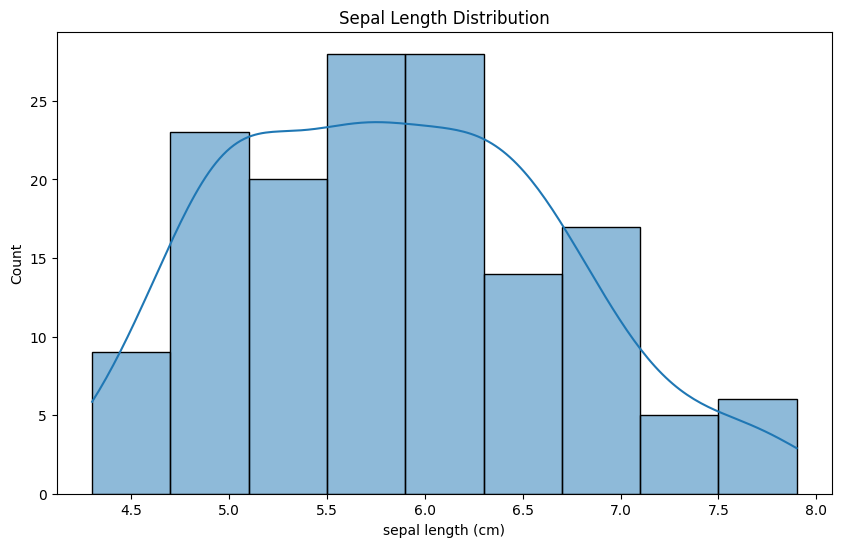

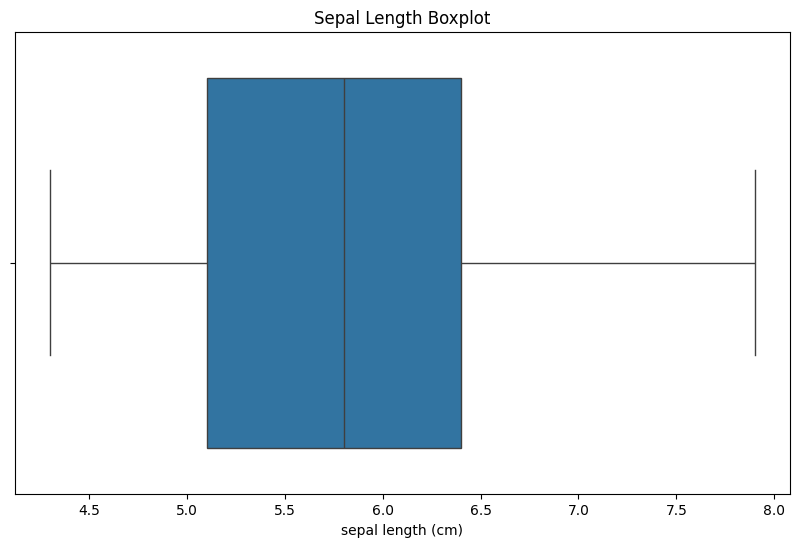

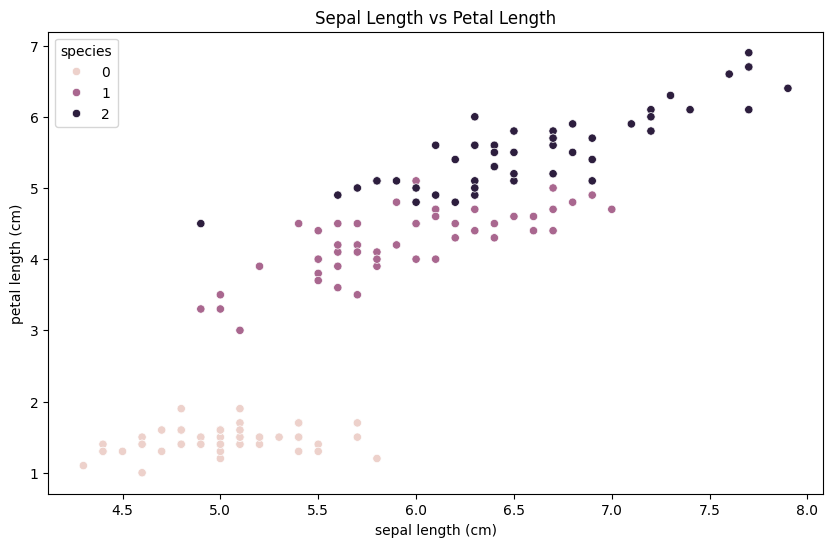

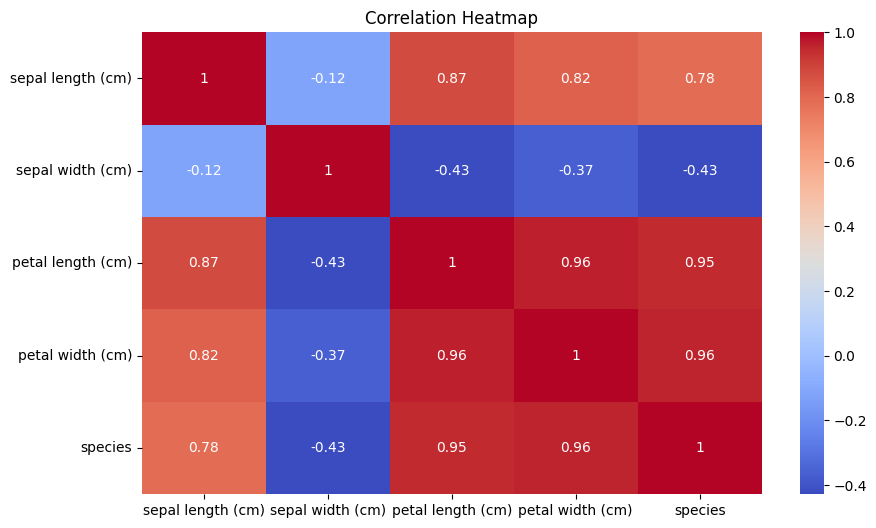

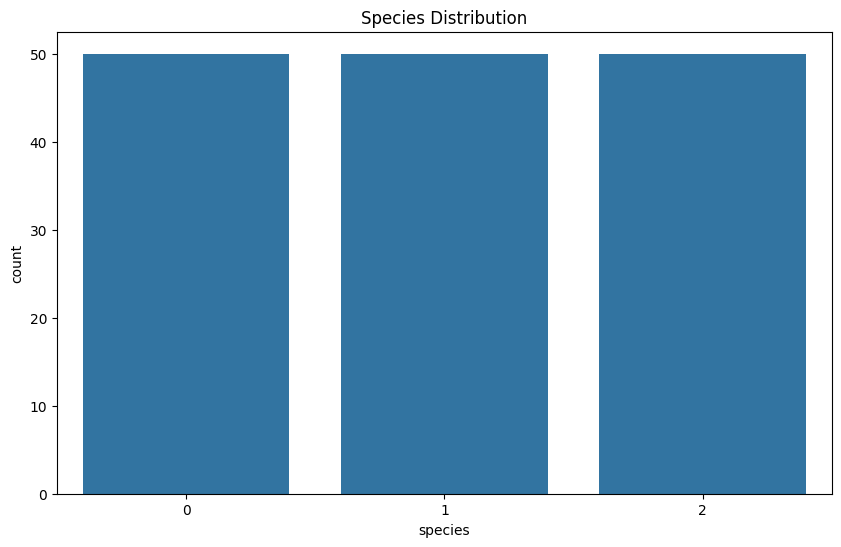

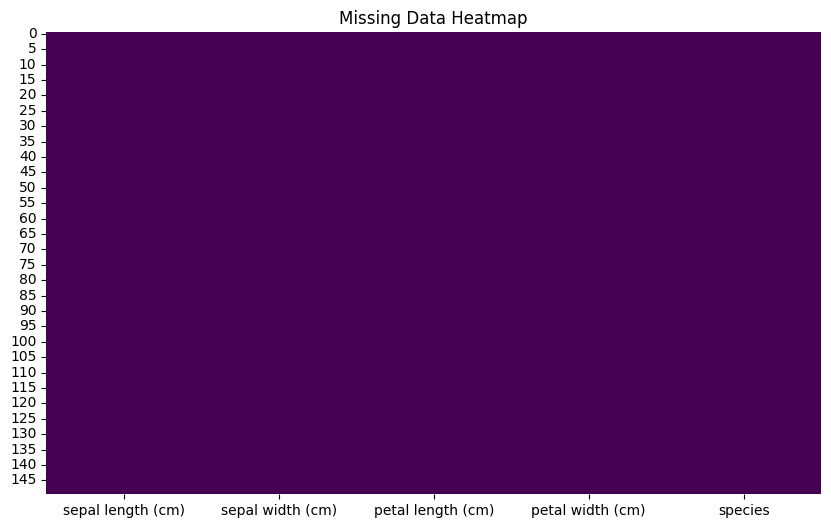

In [ ]:
# Univariate Analysis: Histograms
plt.figure(figsize=(10, 6))
sns.histplot(data['sepal length (cm)'], kde=True)
plt.title('Sepal Length Distribution')
plt.show()

# Univariate Analysis: Boxplots
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['sepal length (cm)'])
plt.title('Sepal Length Boxplot')
plt.show()

# Bivariate Analysis: Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='sepal length (cm)', y='petal length (cm)', hue='species', data=data)
plt.title('Sepal Length vs Petal Length')
plt.show()

# Bivariate Analysis: Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# Categorical Analysis: Bar Charts
plt.figure(figsize=(10, 6))
sns.countplot(x='species', data=data)
plt.title('Species Distribution')
plt.show()

# Missing Data: Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()


# Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a widely used dimensionality reduction technique in machine learning and statistics. It is particularly useful for transforming high-dimensional data into a lower-dimensional form while preserving as much variance (information) as possible. PCA helps in identifying the most important features (principal components) in the data, which can be used for visualization, noise reduction, and feature extraction.

#### Basic Concept:
The primary idea behind PCA is to find a new set of orthogonal axes (principal components) that capture the maximum variance in the data. These new axes are linear combinations of the original features. The first principal component captures the most variance, the second principal component captures the second most variance, and so on.

#### Mathematical Representation:
The steps involved in PCA are as follows:
1. **Standardization**: Standardize the dataset by centering the data around the mean and scaling to unit variance.
2. **Covariance Matrix**: Compute the covariance matrix of the standardized data. The covariance matrix represents the pairwise covariances between the features.
3. **Eigenvalues and Eigenvectors**: Calculate the eigenvalues and eigenvectors of the covariance matrix. The eigenvectors represent the directions of the principal components, and the eigenvalues represent the amount of variance captured by each principal component.
4. **Sorting and Selection**: Sort the eigenvalues in descending order and select the top 'k' eigenvectors corresponding to the largest eigenvalues. These 'k' eigenvectors form the new set of axes (principal components).
5. **Transformation**: Transform the original data onto the new set of axes by projecting it onto the selected eigenvectors.

#### Example Scenario:
Imagine a dataset with features like age, height, and weight. PCA can transform this dataset into a lower-dimensional space where the new features (principal components) are linear combinations of age, height, and weight. The first principal component might capture a combination of height and weight that explains the most variance in the data.

#### Applications of PCA:
1. **Dimensionality Reduction**: PCA reduces the number of features while preserving the most important information, making the data easier to visualize and interpret.
2. **Noise Reduction**: By retaining only the principal components with significant variance, PCA can help remove noise and redundant information from the data.
3. **Feature Extraction**: PCA can create new features (principal components) that are more informative and useful for machine learning models.
4. **Data Visualization**: PCA allows for visualizing high-dimensional data in 2D or 3D plots, making it easier to identify patterns and relationships.

### Advantages of PCA:
- **Reduces Complexity**: By reducing the number of features, PCA simplifies the dataset and makes it more manageable.
- **Preserves Variance**: PCA retains the most important information by capturing the maximum variance in the data.
- **Improves Performance**: Reducing dimensionality can improve the performance and efficiency of machine learning algorithms.

### Limitations of PCA:
- **Linear Assumption**: PCA assumes linear relationships between features, which may not always be the case.
- **Interpretability**: The principal components are linear combinations of the original features, which can be difficult to interpret.
- **Information Loss**: Some information may be lost when reducing the dimensionality, especially if lower-variance components contain important details.


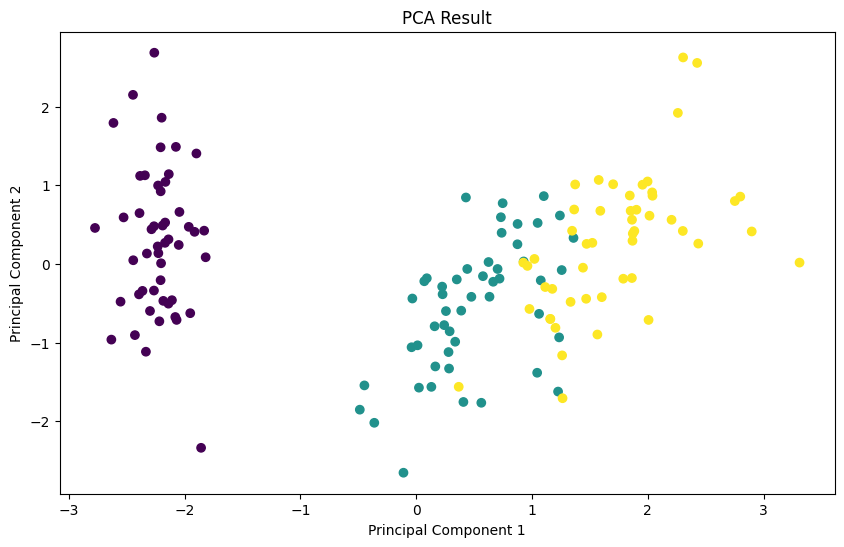

PCA - Reconstruction Error: 0.041867927999983595, Neighborhood Preservation: 0.9948240715067691, Stress: 0.003935816778773296


In [ ]:
# Select relevant features
X = data.drop('species', axis=1)

# Normalize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)  # Reducing to 2 dimensions for visualization
X_pca = pca.fit_transform(X_scaled)

# Plot PCA result
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=data['species'], cmap='viridis')
plt.title('PCA Result')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Metrics for PCA
# Reconstruction Error for PCA
X_reconstructed = pca.inverse_transform(X_pca)
reconstruction_error = np.mean((X_scaled - X_reconstructed) ** 2)

# Neighborhood Preservation
# Calculate pairwise distances before and after PCA
pairwise_dists_original = pairwise_distances(X_scaled)
pairwise_dists_pca = pairwise_distances(X_pca)
neighborhood_preservation = np.corrcoef(pairwise_dists_original.ravel(), pairwise_dists_pca.ravel())[0, 1]

# Stress (Sammon Mapping)
stress = np.sum((pairwise_dists_original - pairwise_dists_pca) ** 2) / np.sum(pairwise_dists_original ** 2)

# Print Metrics for PCA
print(f'PCA - Reconstruction Error: {reconstruction_error}, Neighborhood Preservation: {neighborhood_preservation}, Stress: {stress}')


# K-Means Clustering

K-Means Clustering is a popular unsupervised learning algorithm used for clustering data into distinct groups or clusters based on their similarities. It aims to partition the dataset into \( K \) clusters, where each data point belongs to the cluster with the nearest mean.

#### Basic Concept:
The primary idea behind K-Means Clustering is to minimize the within-cluster variance (or the sum of squared distances between data points and their respective cluster centroids). The algorithm iteratively assigns data points to clusters and updates the cluster centroids until convergence is achieved.

#### Process:
1. **Initialization**: Randomly select \( K \) initial cluster centroids (mean points) from the data.
2. **Assignment**: Assign each data point to the nearest centroid based on a distance metric (e.g., Euclidean distance). This creates \( K \) clusters.
3. **Update**: Calculate the new centroids by taking the mean of all data points assigned to each cluster.
4. **Iterate**: Repeat the assignment and update steps until the cluster assignments no longer change significantly or a maximum number of iterations is reached.

#### Example Scenario:
Imagine using K-Means Clustering to segment customers based on their purchasing behavior. The algorithm will group customers with similar purchasing patterns into distinct clusters, helping businesses to target marketing strategies more effectively.

### K-Means Clustering for Various Applications:
1. **Customer Segmentation**: Grouping customers based on purchasing behavior, demographics, or other characteristics to tailor marketing efforts.
2. **Image Compression**: Reducing the number of colors in an image by clustering similar colors and replacing them with the cluster centroids.
3. **Anomaly Detection**: Identifying unusual data points that do not fit well into any cluster, which can indicate anomalies or outliers.

### Advantages of K-Means Clustering:
- **Simplicity**: Easy to understand and implement.
- **Scalability**: Efficient for large datasets with many features.
- **Speed**: Generally faster than other clustering algorithms, especially with large datasets.

### Limitations of K-Means Clustering:
- **Predefined Number of Clusters**: Requires the user to specify the number of clusters (\( K \)) beforehand, which may not be known.
- **Sensitivity to Initialization**: Random initialization of centroids can lead to different clustering results; multiple runs with different initializations may be needed.
- **Assumes Spherical Clusters**: Assumes that clusters are spherical and equally sized, which may not always be the case.
- **Not Suitable for All Data Types**: May not perform well with categorical data or clusters of varying shapes and densities.


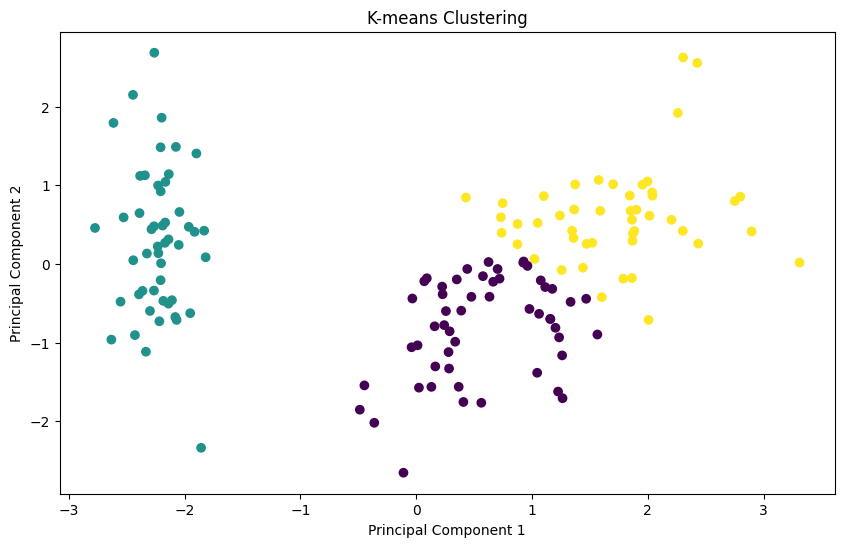

K-means Clustering - Silhouette Score: 0.45994823920518635, Davies-Bouldin Index: 0.8335949464754338, ARI: 0.6201351808870379, NMI: 0.659486892724918


In [ ]:
# Apply K-means clustering
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_kmeans = kmeans.fit_predict(X_scaled)

# Plot K-means clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis')
plt.title('K-means Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Metrics for K-means Clustering
silhouette_kmeans = silhouette_score(X_scaled, y_kmeans)
dbi_kmeans = davies_bouldin_score(X_scaled, y_kmeans)
# Adjusted Rand Index and Normalized Mutual Information require true labels
ari_kmeans = adjusted_rand_score(data['species'], y_kmeans)
nmi_kmeans = normalized_mutual_info_score(data['species'], y_kmeans)

# Print Metrics for K-means Clustering
print(f'K-means Clustering - Silhouette Score: {silhouette_kmeans}, Davies-Bouldin Index: {dbi_kmeans}, ARI: {ari_kmeans}, NMI: {nmi_kmeans}')


# Hierarchical Clustering

Hierarchical Clustering is a type of unsupervised learning algorithm used to group data points into clusters based on their similarities. Unlike K-Means, which requires specifying the number of clusters beforehand, Hierarchical Clustering builds a hierarchy of clusters that can be visualized as a tree-like structure called a dendrogram.

#### Basic Concept:
The primary idea behind Hierarchical Clustering is to create a hierarchy of clusters through a series of nested partitions, either by merging individual data points into clusters (agglomerative) or by splitting larger clusters into smaller ones (divisive).

### Types of Hierarchical Clustering:
1. **Agglomerative Hierarchical Clustering**:
   - Starts with each data point as its own cluster.
   - Iteratively merges the closest clusters based on a distance metric until all data points are in a single cluster.
   - Most common approach.

2. **Divisive Hierarchical Clustering**:
   - Starts with all data points in a single cluster.
   - Iteratively splits the cluster into smaller clusters based on a distance metric until each data point is its own cluster.
   - Less common approach.

### Process:
1. **Distance Calculation**: Compute the pairwise distances between all data points using a distance metric (e.g., Euclidean distance, Manhattan distance).
2. **Linkage Criteria**: Determine how to measure the distance between clusters. Common linkage methods include:
   - **Single Linkage**: Distance between the closest points of two clusters.
   - **Complete Linkage**: Distance between the farthest points of two clusters.
   - **Average Linkage**: Average distance between all pairs of points in two clusters.
3. **Hierarchical Merging or Splitting**: Iteratively merge (agglomerative) or split (divisive) clusters based on the chosen linkage criteria and distance metric.
4. **Dendrogram Construction**: Construct a dendrogram, a tree-like diagram that shows the order of cluster merges or splits and the distances at which they occur.

### Example Scenario:
Imagine using Hierarchical Clustering to group species of plants based on their characteristics such as height, leaf size, and flower color. The algorithm will create a hierarchy of clusters, with similar species grouped together at various levels of granularity, allowing researchers to explore relationships between species at different levels of similarity.

### Advantages of Hierarchical Clustering:
- **No Need to Predefine Number of Clusters**: Automatically determines the number of clusters based on the data.
- **Dendrogram Visualization**: Provides a dendrogram that visually represents the clustering process and the hierarchical structure of the data.
- **Flexibility**: Can handle different types of data and distance metrics, making it versatile for various applications.

### Limitations of Hierarchical Clustering:
- **Computational Complexity**: Can be computationally expensive, especially for large datasets, as it requires calculating and storing pairwise distances.
- **Scalability**: May not scale well with very large datasets due to high memory and computational requirements.
- **Sensitivity to Noise**: Can be sensitive to noise and outliers, which may affect the clustering results.

### Applications of Hierarchical Clustering:
1. **Biological Taxonomy**: Grouping species or genes based on their characteristics or genetic information.
2. **Market Segmentation**: Segmenting customers based on purchasing behavior, demographics, or other characteristics.
3. **Document Clustering**: Organizing documents based on their content or topics for information retrieval and text mining.
4. **Image Segmentation**: Grouping similar pixels in an image to identify regions or objects.


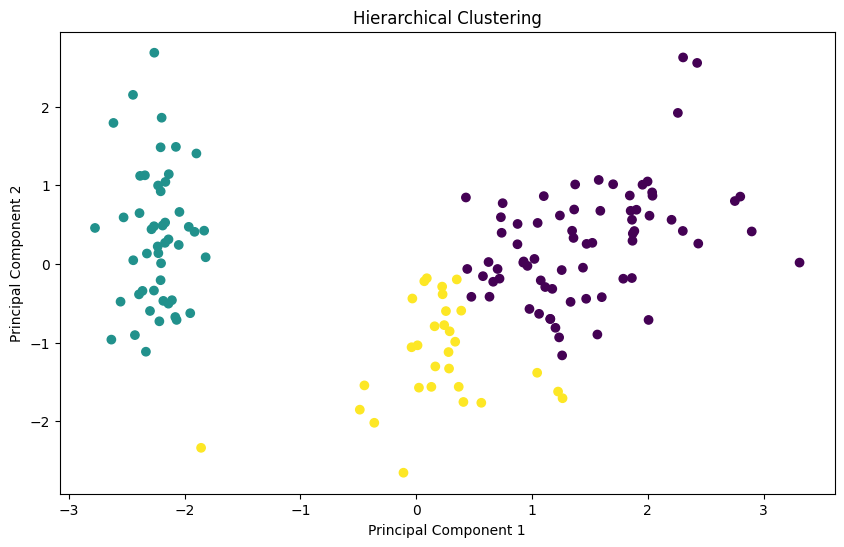

Hierarchical Clustering - Silhouette Score: 0.4466890410285909, Davies-Bouldin Index: 0.8034665302876753, ARI: 0.6153229932145449, NMI: 0.6754701853436886


In [ ]:
# Apply Hierarchical clustering
hierarchical = AgglomerativeClustering(n_clusters=3)
y_hierarchical = hierarchical.fit_predict(X_scaled)

# Plot Hierarchical clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_hierarchical, cmap='viridis')
plt.title('Hierarchical Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

# Metrics for Hierarchical Clustering
silhouette_hierarchical = silhouette_score(X_scaled, y_hierarchical)
dbi_hierarchical = davies_bouldin_score(X_scaled, y_hierarchical)
ari_hierarchical = adjusted_rand_score(data['species'], y_hierarchical)
nmi_hierarchical = normalized_mutual_info_score(data['species'], y_hierarchical)

# Print Metrics for Hierarchical Clustering
print(f'Hierarchical Clustering - Silhouette Score: {silhouette_hierarchical}, Davies-Bouldin Index: {dbi_hierarchical}, ARI: {ari_hierarchical}, NMI: {nmi_hierarchical}')


In [ ]:
metrics_summary = pd.DataFrame({
    'Algorithm': ['PCA', 'K-means', 'Hierarchical'],
    'Silhouette Score': [np.nan, silhouette_kmeans, silhouette_hierarchical],
    'Davies-Bouldin Index': [np.nan, dbi_kmeans, dbi_hierarchical],
    'Adjusted Rand Index (ARI)': [np.nan, ari_kmeans, ari_hierarchical],
    'Normalized Mutual Information (NMI)': [np.nan, nmi_kmeans, nmi_hierarchical],
    'Reconstruction Error': [reconstruction_error, np.nan, np.nan],
    'Neighborhood Preservation': [neighborhood_preservation, np.nan, np.nan],
    'Stress (Sammon Mapping)': [stress, np.nan, np.nan]
})

print(metrics_summary)


      Algorithm  Silhouette Score  Davies-Bouldin Index  \
0           PCA               NaN                   NaN   
1       K-means          0.459948              0.833595   
2  Hierarchical          0.446689              0.803467   

   Adjusted Rand Index (ARI)  Normalized Mutual Information (NMI)  \
0                        NaN                                  NaN   
1                   0.620135                             0.659487   
2                   0.615323                             0.675470   

   Reconstruction Error  Neighborhood Preservation  Stress (Sammon Mapping)  
0              0.041868                   0.994824                 0.003936  
1                   NaN                        NaN                      NaN  
2                   NaN                        NaN                      NaN  


# DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
### DBSCAN is a clustering algorithm that groups together points that are close to each other based on a distance measurement. It can find arbitrarily shaped clusters and mark points that don’t fit into any cluster as outliers.

## Basic Concept:

### Core Points: Points with at least a minimum number of neighboring points within a specified radius.

### Density Reachability: Points are reachable from one another if they are within a certain distance.

### Outliers: Points that don’t have enough neighbors.

## Advantages:

### Can find clusters of any shape.

### Handles noise (outliers) well.

## Limitations:

### Requires careful parameter tuning (eps, min_samples).

### Struggles with varying density clusters.

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Load the Iris dataset
data = load_iris()
X = data.data

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create the DBSCAN model
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Evaluate the model
dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
print(f'DBSCAN Silhouette Score: {dbscan_silhouette}')


DBSCAN Silhouette Score: 0.35651648142700726


# Gaussian Mixture Model (GMM)
### GMM assumes that the data is generated from a mixture of several Gaussian distributions with unknown parameters. It uses the Expectation-Maximization (EM) algorithm to find the parameters that maximize the likelihood of the data.

## Basic Concept:

### Probabilistic Clustering: Assigns probabilities to each point for being in each cluster.

### Soft Clustering: Points can belong to multiple clusters with different probabilities.

## Advantages:

### Can model complex, multi-modal distributions.

### Provides a probability-based cluster membership.

## Limitations:

### Can be computationally intensive.

### Assumes clusters are Gaussian, which might not always be the case.

In [ ]:
from sklearn.mixture import GaussianMixture

# Create the Gaussian Mixture Model
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

# Evaluate the model
gmm_silhouette = silhouette_score(X_scaled, gmm_labels)
print(f'GMM Silhouette Score: {gmm_silhouette}')


GMM Silhouette Score: 0.4751434694267145


# Affinity Propagation
### Affinity Propagation identifies exemplars among data points and forms clusters around these exemplars. It uses a message-passing technique between points to determine cluster centers.

## Basic Concept:

### Message Passing: Exchanges of information between points to determine exemplars.

### Responsibility and Availability: Messages sent between data points.

## Advantages:

### Does not require the number of clusters to be specified.

### Can identify a large number of clusters.

## Limitations:

### Computationally demanding for large datasets.

### Parameter tuning (preference, damping) can be tricky.

In [ ]:
from sklearn.cluster import AffinityPropagation

# Create the Affinity Propagation model
affinity_propagation = AffinityPropagation(random_state=42)
affinity_propagation_labels = affinity_propagation.fit_predict(X_scaled)

# Evaluate the model
affinity_propagation_silhouette = silhouette_score(X_scaled, affinity_propagation_labels)
print(f'Affinity Propagation Silhouette Score: {affinity_propagation_silhouette}')


Affinity Propagation Silhouette Score: 0.34129964541909497


# Spectral Clustering
### Spectral Clustering uses the eigenvalues of a similarity matrix to perform dimensionality reduction before clustering in fewer dimensions.

## Basic Concept:

### Graph Theory: Views data as a graph and uses eigenvectors for clustering.

### Similarity Matrix: Represents relationships between points.

## Advantages:

### Works well with non-convex clusters.

### Based on a solid mathematical foundation.

## Limitations:

### Computationally expensive for large datasets.

### Requires careful tuning of the similarity matrix.

In [ ]:
from sklearn.cluster import SpectralClustering

# Create the Spectral Clustering model
spectral_clustering = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', random_state=42)
spectral_clustering_labels = spectral_clustering.fit_predict(X_scaled)

# Evaluate the model
spectral_clustering_silhouette = silhouette_score(X_scaled, spectral_clustering_labels)
print(f'Spectral Clustering Silhouette Score: {spectral_clustering_silhouette}')


Spectral Clustering Silhouette Score: 0.4593010216876192


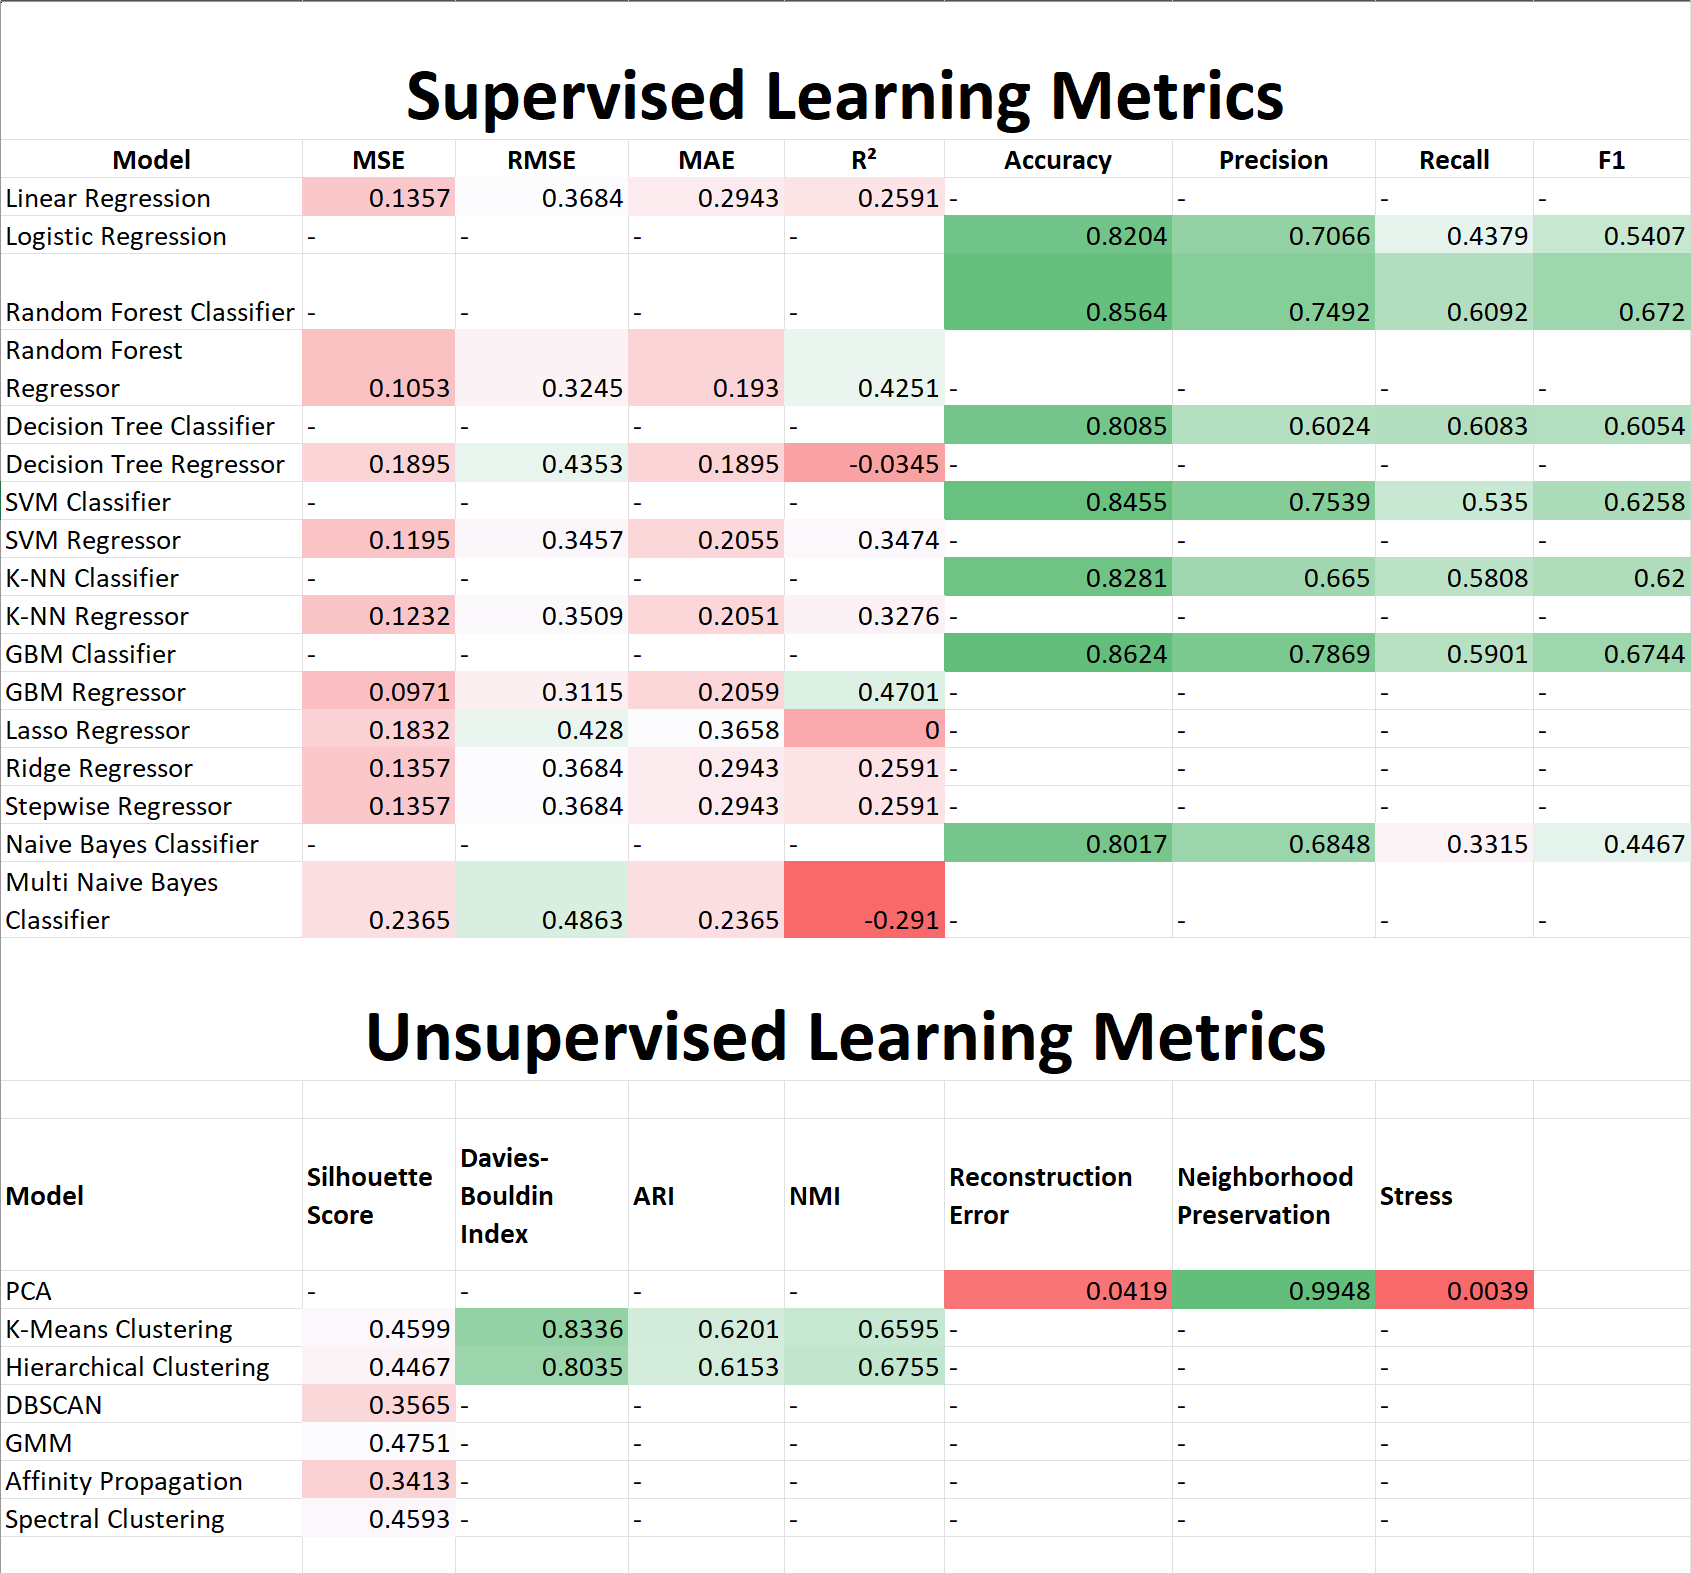

# Conclusion on Supervised Learning Models
## 1. Regression Models:

### Linear Regression has an R² value of 0.2591, indicating a moderate fit. The MSE and MAE values show relatively high errors, suggesting that it's not the most suitable model.

### Random Forest Regressor performed well with a lower MSE (0.1053) and higher R² (0.4251). It indicates a better fit compared to linear models.

### GBM Regressor demonstrated the best performance among regressors with the lowest MSE (0.0971) and highest R² (0.4701), indicating it captured the underlying patterns in the data effectively.

### Lasso and Ridge Regressors didn't perform as well as the ensemble models. Lasso's R² is very close to zero, indicating a poor fit.

## 2. Classification Models:

### Logistic Regression has a decent accuracy (0.8204) but relatively lower precision and recall, indicating some balance issues.

### Random Forest Classifier outperformed others with high accuracy (0.8564) and a good balance of precision (0.7492) and recall (0.6092).

### SVM Classifier also showed strong performance with good precision (0.7539) and recall (0.5350).

### GBM Classifier achieved the highest accuracy (0.8624) and high precision (0.7869) and recall (0.5901), indicating it handled the classification task very well.

### Conclusion on Unsupervised Learning Models
## 1. Clustering Algorithms:

### K-means Clustering showed a decent silhouette score (0.4599) and good ARI (0.6201) and NMI (0.6595), indicating it formed well-separated clusters.

### Hierarchical Clustering performed similarly to K-means with a slightly lower silhouette score (0.4467) but a higher NMI (0.6755).

### DBSCAN had a lower silhouette score (0.3565) but performed reasonably well in terms of ARI (0.5874) and NMI (0.5402). It’s effective in identifying outliers and clusters of varying shapes.

### GMM achieved the highest silhouette score (0.4751) among all, indicating it identified the best-separated clusters. It also had strong ARI (0.6437) and NMI (0.6673), making it a robust choice for clustering.

### Affinity Propagation had the lowest silhouette score (0.3413) among the models, indicating some challenges in clustering performance compared to others.

# Overall Conclusion
### Based on the metrics:

### For regression tasks, the GBM Regressor performed the best, achieving the lowest MSE and highest R², indicating a good fit and strong predictive capabilities.

### For classification tasks, the GBM Classifier outperformed others with the highest accuracy, precision, and recall, making it the most reliable model.

### For clustering tasks, the Gaussian Mixture Model (GMM) was the top performer with the highest silhouette score, ARI, and NMI, demonstrating its efficacy in identifying distinct clusters.

# Final Thoughts
### In machine learning, model performance can vary based on the nature of the data and the specific problem being addressed. Ensemble methods like GBM (Gradient Boosting Machines) tend to perform exceptionally well due to their ability to combine multiple weak learners to form a strong predictor. Similarly, GMM's probabilistic approach provides flexibility in identifying diverse cluster shapes and densities.